# Experiment 2C: Ablation - CAS Grid Search

**Experiment:** Exp 2C

Ablation study: CAS grid search across different N (synthetic samples) and truncation psi values (Table 5.19, Figure 5.9).

---

In [2]:
import os
!pip install gdown --upgrade

if os.path.isdir("/content/drive/MyDrive/colab-sg2-ada-pytorch"):
    %cd "/content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch"
elif os.path.isdir("/content/drive/"):
    #install script
    %cd "/content/drive/MyDrive/"
    !mkdir colab-sg2-ada-pytorch
    %cd colab-sg2-ada-pytorch
    !git clone https://github.com/JunTierSS/stylegan2-ada
    %cd stylegan2-ada-pytorch
    !mkdir downloads
    !mkdir datasets
    !mkdir pretrained
    !gdown --id 1-5xZkD8ajXw1DdopTkH_rAoCsD72LhKU -O /content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch/pretrained/wikiart.pkl
else:
    !git clone https://github.com/JunTierSS/stylegan2-ada
    %cd stylegan2-ada-pytorch
    !mkdir downloads
    !mkdir datasets
    !mkdir pretrained
    %cd pretrained
    !gdown --id 1-5xZkD8ajXw1DdopTkH_rAoCsD72LhKU
    %cd ../

/content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch


In [3]:
# (2) Rutas
ZIP ="/content/drive/MyDrive/TESIS/splits/by_patient_30test1/train.zip"
DEST = "/content/localdata"                 # carpeta base local
UNZIP_DIR = f"{DEST}/trainori_unzipped"        # donde se extraerá el zip

import os, shutil, pathlib, subprocess

# (3) Crear carpeta destino y copiar el ZIP localmente (I/O mucho más rápido)
os.makedirs(DEST, exist_ok=True)
local_zip = f"{DEST}/trainori.zip"
shutil.copy2(ZIP, local_zip)
print("ZIP copiado a:", local_zip)

# (4) Descomprimir (silencioso, sobrescribe si ya existe)
os.makedirs(UNZIP_DIR, exist_ok=True)
!unzip -q -o "/content/localdata/trainori.zip" -d "/content/localdata/trainori_unzipped"

# (5) (Opcional) eliminar carpeta __MACOSX si existe
!find "/content/localdata/trainori_unzipped" -type d -name "__MACOSX" -prune -exec rm -rf {} +

# (6) Mostrar estructura principal para que ubiques DATA_ROOT / TEST_ROOT
print("Contenido de", UNZIP_DIR)
!ls -lah "/content/localdata/trainori_unzipped" | head -n 50

ZIP copiado a: /content/localdata/trainori.zip
Contenido de /content/localdata/trainori_unzipped
total 128K
drwxr-xr-x 5 root root 4.0K Nov 20 23:28 .
drwxr-xr-x 3 root root 4.0K Nov 20 23:28 ..
drwxr-xr-x 2 root root  48K Nov 20 23:28 glioma
drwxr-xr-x 2 root root  36K Nov 20 23:28 meningioma
drwxr-xr-x 2 root root  36K Nov 20 23:28 pituitary


In [4]:
# (2) Rutas
ZIP ="/content/drive/MyDrive/TESIS/splits/by_patient_30test1/test.zip"
DEST = "/content/localdata"                 # carpeta base local
UNZIP_DIR = f"{DEST}/testori_unzipped"        # donde se extraerá el zip

import os, shutil, pathlib, subprocess

# (3) Crear carpeta destino y copiar el ZIP localmente (I/O mucho más rápido)
os.makedirs(DEST, exist_ok=True)
local_zip = f"{DEST}/testori.zip"
shutil.copy2(ZIP, local_zip)
print("ZIP copiado a:", local_zip)

# (4) Descomprimir (silencioso, sobrescribe si ya existe)
os.makedirs(UNZIP_DIR, exist_ok=True)
!unzip -q -o "/content/localdata/testori.zip" -d "/content/localdata/testori_unzipped"

# (5) (Opcional) eliminar carpeta __MACOSX si existe
!find "/content/localdata/testori_unzipped" -type d -name "__MACOSX" -prune -exec rm -rf {} +

# (6) Mostrar estructura principal para que ubiques DATA_ROOT / TEST_ROOT
print("Contenido de", UNZIP_DIR)
!ls -lah "/content/localdata/testori_unzipped" | head -n 50

ZIP copiado a: /content/localdata/testori.zip
Contenido de /content/localdata/testori_unzipped
total 60K
drwxr-xr-x 5 root root 4.0K Nov 20 23:28 .
drwxr-xr-x 4 root root 4.0K Nov 20 23:28 ..
drwxr-xr-x 2 root root  20K Nov 20 23:28 glioma
drwxr-xr-x 2 root root  12K Nov 20 23:28 meningioma
drwxr-xr-x 2 root root  20K Nov 20 23:28 pituitary


In [5]:
# (2) Rutas
ZIP ="/content/drive/MyDrive/TESIS/datasetinge/testreducido.zip"
DEST = "/content/localdata"                 # carpeta base local
UNZIP_DIR = f"{DEST}/test_unzipped"        # donde se extraerá el zip

import os, shutil, pathlib, subprocess

# (3) Crear carpeta destino y copiar el ZIP localmente (I/O mucho más rápido)
os.makedirs(DEST, exist_ok=True)
local_zip = f"{DEST}/test.zip"
shutil.copy2(ZIP, local_zip)
print("ZIP copiado a:", local_zip)

# (4) Descomprimir (silencioso, sobrescribe si ya existe)
os.makedirs(UNZIP_DIR, exist_ok=True)
!unzip -q -o "/content/localdata/test.zip" -d "/content/localdata/test_unzipped"

# (5) (Opcional) eliminar carpeta __MACOSX si existe
!find "/content/localdata/test_unzipped" -type d -name "__MACOSX" -prune -exec rm -rf {} +

# (6) Mostrar estructura principal para que ubiques DATA_ROOT / TEST_ROOT
print("Contenido de", UNZIP_DIR)
!ls -lah "/content/localdata/test_unzipped" | head -n 50

ZIP copiado a: /content/localdata/test.zip
Contenido de /content/localdata/test_unzipped
total 12K
drwxr-xr-x 3 root root 4.0K Nov 20 23:28 .
drwxr-xr-x 5 root root 4.0K Nov 20 23:28 ..
drwxrwxrwx 5 root root 4.0K Nov 10 21:19 testreducido


In [6]:
# (2) Rutas
ZIP ="/content/drive/MyDrive/TESIS/datasetinge/trainreducido.zip"
DEST = "/content/localdata"                 # carpeta base local
UNZIP_DIR = f"{DEST}/train_unzipped"        # donde se extraerá el zip

import os, shutil, pathlib, subprocess

# (3) Crear carpeta destino y copiar el ZIP localmente (I/O mucho más rápido)
os.makedirs(DEST, exist_ok=True)
local_zip = f"{DEST}/train.zip"
shutil.copy2(ZIP, local_zip)
print("ZIP copiado a:", local_zip)

# (4) Descomprimir (silencioso, sobrescribe si ya existe)
os.makedirs(UNZIP_DIR, exist_ok=True)
!unzip -q -o "/content/localdata/train.zip" -d "/content/localdata/train_unzipped"

# (5) (Opcional) eliminar carpeta __MACOSX si existe
!find "/content/localdata/train_unzipped" -type d -name "__MACOSX" -prune -exec rm -rf {} +

# (6) Mostrar estructura principal para que ubiques DATA_ROOT / TEST_ROOT
print("Contenido de", UNZIP_DIR)
!ls -lah "/content/localdata/train_unzipped" | head -n 50

ZIP copiado a: /content/localdata/train.zip
Contenido de /content/localdata/train_unzipped
total 12K
drwxr-xr-x 3 root root 4.0K Nov 20 23:29 .
drwxr-xr-x 6 root root 4.0K Nov 20 23:29 ..
drwxrwxrwx 5 root root 4.0K Nov 10 21:19 trainreducido


In [7]:
pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.0 MB/s eta 0:00:00


In [8]:
pip install opensimplex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 17.4 MB/s eta 0:00:00


In [9]:

import os, re, io, json, time, argparse, random, csv, shutil, pickle
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torchvision.transforms.functional as TF
import torchvision

from sklearn.model_selection import StratifiedShuffleSplit

In [10]:
# -*- coding: utf-8 -*-
"""
K-Fold training (by patient) for brain tumor classification (ResNet50)
- No-leak by patient_id (groups)
- StratifiedGroupKFold if available; fallback to GroupKFold
- Optional StyleGAN2-ADA augmentation:
    * Real-only run (no GAN)
    * GAN-balanced run: para cada fold se agrega GAN hasta igualar la clase mayor (por nº de imágenes REALES)
- Per-fold metrics + CV summary
- OOF (out-of-fold) predictions & metrics (one row per pool sample, predicted by a model that didn't see it)
- External TEST evaluation per fold + K-fold ensemble (avg probs across folds)
- Full INTTEST metrics per fold + INTTEST ensemble, and CV summary with mean±std for VAL/INTTEST/TEST
- Optional final fine-tuning epochs using only REAL images (no GAN) per fold and in full-train

Author: Jun + ChatGPT
"""

import os, re, io, json, time, random, csv, math, shutil, pickle
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass, asdict

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# ====== Splitters ======
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_SGTK = True
except Exception:
    HAS_SGTK = False
    from sklearn.model_selection import GroupKFold

# ====== Utils ======

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def timestamp() -> str:
    return time.strftime("%Y%m%d-%H%M%S")

def extract_patient_id(p: Path) -> str:
    stem = p.stem
    token = stem.split("_")[0]
    return token.strip().lower()

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# ====== Config ======

@dataclass
class Config:
    data_root: str
    out_dir: str
    test_root: str = ""
    gan_pkl: str = ""
    images_per_class: int = 0        # sólo se usa si balance_gan_to_max=False
    truncation: float = 1.0
    internal_test_ratio: float = 0.0   # optional: holdout before CV
    image_size: int = 256
    batch_size: int = 32
    epochs: int = 15
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 4
    seed: int = 42
    kfolds: int = 5
    amp: bool = True
    pretrained: bool = True
    train_full_after_cv: bool = False   # optional: retrain on full pool at end

    # Fine-tuning final sólo con reales
    fine_tune_real_epochs: int = 0      # 0 = desactivado

    # NUEVO: balancear clases con GAN hasta la clase mayor de REALES
    balance_gan_to_max: bool = False

# ====== Dataset ======

class MRIDataset(Dataset):
    def __init__(self, items: List[Tuple[Path, int, str]], image_size: int = 256, aug: bool = False):
        self.items = items
        self.image_size = image_size
        self.aug = aug
        mean = [0.5, 0.5, 0.5]; std = [0.5, 0.5, 0.5]
        if aug:
            self.tf = transforms.Compose([
                transforms.RandomResizedCrop(image_size, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(10),
                transforms.ToTensor(),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
            ])
        self.norm = transforms.Normalize(mean=mean, std=std)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y, pid = self.items[idx]
        img = Image.open(path).convert("L")
        img = self.tf(img)           # [1,H,W]
        img = img.repeat(3, 1, 1)    # [3,H,W]
        img = self.norm(img)
        return img, y, str(path), pid

# ====== Scan & Helpers ======

def scan_folder(root: Path) -> Tuple[List[Tuple[Path,int,str]], List[str]]:
    assert root.is_dir(), f"Not a directory: {root}"
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    items: List[Tuple[Path,int,str]] = []
    for ci, cname in enumerate(class_names):
        cdir = root / cname
        for p in cdir.rglob("*"):
            if p.suffix.lower() in IMG_EXTS:
                pid = extract_patient_id(p)
                items.append((p, ci, pid))
    return items, class_names

def ensure_no_overlap(ids_a: List[str], ids_b: List[str]) -> Tuple[int, List[str]]:
    a = set(ids_a); b = set(ids_b)
    inter = sorted(a.intersection(b))
    return len(inter), inter

def summarize_id_counts(items: List[Tuple[Path,int,str]], class_names: List[str], split_name: str, out_dir: Path):
    from collections import defaultdict
    ids_by_class = defaultdict(set); imgs_by_class = defaultdict(int); all_ids = set()
    for p, ci, pid in items:
        ids_by_class[ci].add(pid)
        imgs_by_class[ci] += 1
        all_ids.add(pid)

    print(f"[ID-STATS] {split_name}: unique patient IDs total = {len(all_ids)} | images = {len(items)}")
    for ci, cname in enumerate(class_names):
        print(f"  - {cname}: ids={len(ids_by_class[ci])} images={imgs_by_class[ci]}")

    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / f"id_counts_{split_name}.csv", 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["class", "n_unique_ids", "n_images"])
        for ci, cname in enumerate(class_names):
            w.writerow([cname, len(ids_by_class[ci]), imgs_by_class[ci]])
        w.writerow(["__TOTAL__", len(all_ids), len(items)])

# ====== Model ======

def build_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None)
    in_features = m.fc.in_features
    m.fc = nn.Linear(in_features, num_classes)
    return m

# ====== Eval (writes artifacts) ======

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device, class_names: List[str], split_name: str, out_dir: Path):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    all_paths, all_pids = [], []

    for imgs, ys, paths, pids in loader:
        imgs = imgs.to(device, non_blocking=True)
        ys = ys.to(device, non_blocking=True)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(ys.cpu().numpy())
        all_paths.extend(list(paths))
        all_pids.extend(list(pids))

    probs = np.concatenate(all_probs, axis=0) if all_probs else np.zeros((0, len(class_names)))
    preds = np.concatenate(all_preds, axis=0) if all_preds else np.zeros((0,), dtype=np.int64)
    labels = np.concatenate(all_labels, axis=0) if all_labels else np.zeros((0,), dtype=np.int64)

    acc = float(accuracy_score(labels, preds)) if len(labels) else 0.0
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    per_class = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=list(range(len(class_names))))

    metrics = {
        "overall": {
            "accuracy": acc,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "precision_weighted": prec_weighted,
            "recall_weighted": rec_weighted,
            "f1_weighted": f1_weighted,
            "num_samples": len(labels),
        },
        "per_class": per_class,
    }

    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / f"metrics_{split_name}.json", 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2)

    with open(out_dir / f"metrics_overall_{split_name}.csv", 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["split","accuracy","precision_macro","recall_macro","f1_macro","precision_weighted","recall_weighted","f1_weighted","num_samples"])
        o = metrics['overall']
        w.writerow([split_name, o['accuracy'], o['precision_macro'], o['recall_macro'], o['f1_macro'],
                    o['precision_weighted'], o['recall_weighted'], o['f1_weighted'], o['num_samples']])

    with open(out_dir / f"per_class_{split_name}.csv", 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["class", "precision", "recall", "f1", "support"])
        for cname in class_names:
            row = per_class.get(cname, {"precision":0, "recall":0, "f1-score":0, "support":0})
            w.writerow([cname, row.get("precision",0), row.get("recall",0),
                        row.get("f1-score",0), row.get("support",0)])

    with open(out_dir / f"confusion_{split_name}.csv", 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["true\\pred"] + class_names)
        for i, cname in enumerate(class_names):
            w.writerow([cname] + list(cm[i]))

    with open(out_dir / f"predictions_{split_name}.csv", 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["path", "patient_id", "true", "pred"] + [f"p_{c}" for c in class_names])
        for i in range(len(labels)):
            w.writerow([all_paths[i], all_pids[i], class_names[labels[i]],
                        class_names[preds[i]]] + list(map(float, probs[i].tolist())))

    return metrics, cm

# Helper: fast inference to collect arrays (for OOF & ensemble)
@torch.no_grad()
def infer_loader(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    paths, pids = [], []
    all_probs, all_preds, all_labels = [], [], []
    for imgs, ys, batch_paths, batch_pids in loader:
        imgs = imgs.to(device, non_blocking=True)
        ys = ys.to(device, non_blocking=True)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(ys.cpu().numpy())
        paths.extend(list(batch_paths))
        pids.extend(list(batch_pids))

    probs = np.concatenate(all_probs, axis=0) if all_probs else np.zeros((0, 0))
    preds = np.concatenate(all_preds, axis=0) if all_preds else np.zeros((0,), dtype=np.int64)
    labels = np.concatenate(all_labels, axis=0) if all_labels else np.zeros((0,), dtype=np.int64)
    return {"probs": probs, "preds": preds, "labels": labels, "paths": paths, "pids": pids}

# ====== Optional GAN loader (TRAIN only) ======

@torch.no_grad()
def _load_stylegan2_ada_G(gan_pkl: str, device: torch.device):
    try:
        import dnnlib
        from training import network as _dummy
        from legacy import load_network_pkl
    except Exception:
        try:
            from torch_utils import misc as _m  # noqa
            from torch_utils import training_stats as _ts  # noqa
            from legacy import load_network_pkl
        except Exception:
            return None
    try:
        with open(gan_pkl, 'rb') as f:
            data = load_network_pkl(f)
        G_ema = data.get('G_ema', None) or data.get('G', None)
        if G_ema is None:
            return None
        G_ema = G_ema.to(device)
        G_ema.eval()
        return G_ema
    except Exception:
        return None

@torch.no_grad()
def maybe_generate_gan_images(gan_pkl: str,
                              class_names: List[str],
                              n_per_class: int,
                              truncation: float,
                              out_dir: Path,
                              device: torch.device,
                              seed: int = 42) -> Optional[Path]:
    if (not gan_pkl) or n_per_class <= 0:
        return None
    G = _load_stylegan2_ada_G(gan_pkl, device)
    if G is None:
        print("[GAN] Could not load StyleGAN2-ADA G_ema. Skipping GAN augmentation.")
        return None
    if getattr(G, 'c_dim', 0) <= 0:
        print("[GAN] Generator is not conditional (c_dim=0). Skipping.")
        return None

    rng = np.random.RandomState(seed)
    synth_root = out_dir / "gan_synth"
    for cname in class_names:
        (synth_root / cname).mkdir(parents=True, exist_ok=True)

    batch = 16
    for ci, cname in enumerate(class_names):
        saved = 0
        while saved < n_per_class:
            bs = min(batch, n_per_class - saved)
            z = torch.from_numpy(rng.randn(bs, G.z_dim)).to(device)
            c = torch.zeros(bs, G.c_dim, device=device); c[:, ci] = 1.0
            try:
                img = G(z, c, truncation_psi=float(truncation), noise_mode='const')
            except TypeError:
                img = G(z, c, truncation_psi=float(truncation))
            img = (img * 127.5 + 128).clamp(0,255).to(torch.uint8).cpu()
            for k in range(bs):
                x = img[k]
                if x.shape[0] == 1:
                    arr = x[0].numpy()
                    pil = Image.fromarray(arr).convert('L')
                else:
                    arr = x.permute(1,2,0).numpy()
                    pil = Image.fromarray(arr).convert('L')
                fname = synth_root / cname / f"gan_{cname}_{saved+k:05d}.png"
                pil.save(fname)
            saved += bs
        print(f"[GAN] Saved {saved} images for class '{cname}'")
    return synth_root

def collate_fn(batch):
    imgs, ys, paths, pids = zip(*batch)
    return torch.stack(imgs, dim=0), torch.tensor(ys, dtype=torch.long), list(paths), list(pids)

# ====== Helper: construir subset balanceado real + GAN ======

def build_balanced_train_subset(real_train_subset: List[Tuple[Path,int,str]],
                                synth_items: List[Tuple[Path,int,str]],
                                num_classes: int,
                                seed: int) -> List[Tuple[Path,int,str]]:
    """
    Toma:
      - real_train_subset: sólo imágenes reales de ese fold
      - synth_items: TODAS las sintéticas (escaneadas desde gan_synth/)
    Devuelve:
      - lista con reales + suficientes GAN por clase para igualar la clase mayor (en REALES).
    """
    from collections import defaultdict

    # Reales por clase
    real_by_class: Dict[int, List[Tuple[Path,int,str]]] = defaultdict(list)
    for item in real_train_subset:
        _, ci, _ = item
        real_by_class[ci].append(item)

    # GAN por clase
    synth_by_class: Dict[int, List[Tuple[Path,int,str]]] = defaultdict(list)
    for item in synth_items:
        _, ci, _ = item
        synth_by_class[ci].append(item)

    # Target = tamaño de la clase mayor (sólo contando REALES)
    counts_real = [len(real_by_class[c]) for c in range(num_classes)]
    target = max(counts_real) if counts_real else 0
    print(f"[BAL] Real class counts (fold): {counts_real} -> target={target}")

    rng = random.Random(seed)
    balanced: List[Tuple[Path,int,str]] = list(real_train_subset)

    for ci in range(num_classes):
        need = target - len(real_by_class[ci])
        if need <= 0:
            continue
        pool = synth_by_class[ci]
        if not pool:
            print(f"[BAL] WARNING: no GAN images for class {ci}, cannot fully balance.")
            continue
        # muestramos con reemplazo si need > len(pool)
        for _ in range(need):
            balanced.append(rng.choice(pool))

    return balanced

# ====== K-Fold Train (CV + OOF + TEST + INTTEST ensemble) ======

def train_kfold(cfg: Config):
    if cfg.fine_tune_real_epochs < 0 or cfg.fine_tune_real_epochs > cfg.epochs:
        raise ValueError("fine_tune_real_epochs must be between 0 and cfg.epochs")

    base_run = Path(cfg.out_dir) / f"kfold_{cfg.kfolds}f_run_{timestamp()}"
    base_run.mkdir(parents=True, exist_ok=True)
    with open(base_run / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(asdict(cfg), f, indent=2)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"[Device] Using {device}")

    # Scan pool
    all_items, class_names = scan_folder(Path(cfg.data_root))
    print(f"[Scan] Pool images: {len(all_items)} | Classes: {class_names}")

    # Optional internal-test holdout (by patient)
    inttest_subset: List[Tuple[Path,int,str]] = []
    if cfg.internal_test_ratio and cfg.internal_test_ratio > 0:
        from sklearn.model_selection import GroupShuffleSplit
        X_all = np.arange(len(all_items))
        y_all = np.array([lbl for _, lbl, _ in all_items])
        g_all = np.array([pid for _, _, pid in all_items])
        gss = GroupShuffleSplit(n_splits=1, test_size=cfg.internal_test_ratio, random_state=cfg.seed)
        trval_idx, inttest_idx = next(gss.split(X_all, y_all, g_all))
        base_pool = [all_items[i] for i in trval_idx]
        inttest_subset = [all_items[i] for i in inttest_idx]
        print(f"[Split] Internal test: {len(inttest_subset)} images ({cfg.internal_test_ratio*100:.1f}%)")
    else:
        base_pool = all_items

    # External test (leak-sanitized vs pool & internal test)
    ext_subset: List[Tuple[Path,int,str]] = []
    if cfg.test_root and len(cfg.test_root.strip()) > 0 and Path(cfg.test_root).exists():
        ext_items, _ = scan_folder(Path(cfg.test_root))
        ids_pool = set(pid for _,_,pid in base_pool)
        if len(inttest_subset) > 0:
            ids_pool |= set(pid for _,_,pid in inttest_subset)
        for it in ext_items:
            if it[2] not in ids_pool:
                ext_subset.append(it)
        removed = len(ext_items) - len(ext_subset)
        if removed > 0:
            print(f"[LEAK-FIX] Removed {removed} overlapping ext-test images by patient ID.")
        print(f"[Scan] External test images (sanitized): {len(ext_subset)}")

    # Build folds grouped by patient (SOLO con REALES)
    X = np.arange(len(base_pool))
    y = np.array([lbl for _, lbl, _ in base_pool])
    groups = np.array([pid for _, _, pid in base_pool])

    if cfg.kfolds < 2:
        raise ValueError("kfolds must be >= 2")

    if HAS_SGTK:
        splitter = StratifiedGroupKFold(n_splits=cfg.kfolds, shuffle=True, random_state=cfg.seed)
        folds_iter = list(splitter.split(X, y, groups))
        print("[Split] Using StratifiedGroupKFold")
    else:
        splitter = GroupKFold(n_splits=cfg.kfolds)
        folds_iter = list(splitter.split(X, groups=groups))
        print("[Split] Using GroupKFold (no stratification)")

    # ===== Pre-generate GAN synth una sola vez =====
    synth_items: List[Tuple[Path,int,str]] = []
    synth_root: Optional[Path] = None
    if cfg.gan_pkl and cfg.gan_pkl.strip():
        # si queremos balancear, ignoramos images_per_class y usamos el máximo global de REALES
        if cfg.balance_gan_to_max:
            from collections import defaultdict
            real_counts_global = defaultdict(int)
            for _, ci, _ in base_pool:
                real_counts_global[ci] += 1
            # Vector ordenado por índice de clase
            counts_vec = [real_counts_global[ci] for ci in range(len(class_names))]
            n_per_class = max(counts_vec) if counts_vec else 0
            print(f"[GAN] balance_gan_to_max=True -> global real counts per class = {counts_vec}, using n_per_class={n_per_class}")
        else:
            n_per_class = cfg.images_per_class

        if n_per_class > 0:
            synth_root = maybe_generate_gan_images(
                gan_pkl=cfg.gan_pkl,
                class_names=class_names,
                n_per_class=n_per_class,
                truncation=cfg.truncation,
                out_dir=base_run,
                device=device,
                seed=cfg.seed,
            )
            if synth_root is not None:
                synth_items, _ = scan_folder(synth_root)
                print(f"[GAN] Synth images generated (global): {len(synth_items)}")
        else:
            print("[GAN] n_per_class <= 0 -> no synthetic images will be generated.")
    else:
        print("[GAN] gan_pkl empty -> NO GAN will be used.")

    # Prepare fixed loaders for ensembles (TEST e INTTEST)
    test_loader_fixed: Optional[DataLoader] = None
    test_ref_paths = test_ref_pids = test_ref_labels = None
    if len(ext_subset) > 0:
        test_ds_fixed = MRIDataset(ext_subset, image_size=cfg.image_size, aug=False)
        test_loader_fixed = DataLoader(test_ds_fixed, batch_size=cfg.batch_size, shuffle=False,
                                       num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)
        # Se rellenan luego con infer_loader

    inttest_loader_fixed: Optional[DataLoader] = None
    int_ref_paths = int_ref_pids = int_ref_labels = None
    if len(inttest_subset) > 0:
        int_ds_fixed = MRIDataset(inttest_subset, image_size=cfg.image_size, aug=False)
        inttest_loader_fixed = DataLoader(int_ds_fixed, batch_size=cfg.batch_size, shuffle=False,
                                          num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)

    # ===== OOF buffers =====
    n_pool = len(base_pool)
    n_cls = len(class_names)
    oof_probs = np.full((n_pool, n_cls), np.nan, dtype=np.float32)
    oof_pred  = np.full((n_pool,), -1, dtype=np.int64)
    oof_true  = np.full((n_pool,), -1, dtype=np.int64)
    oof_path  = [""] * n_pool
    oof_pid   = [""] * n_pool

    # For ensembles
    test_probs_folds: List[np.ndarray] = []
    inttest_probs_folds: List[np.ndarray] = []

    # Per-fold training
    cv_rows = []
    for fold_id, (tr_idx, va_idx) in enumerate(folds_iter, start=1):
        print(f"\n===== FOLD {fold_id}/{cfg.kfolds} =====")
        set_seed(cfg.seed + fold_id)

        fold_dir = base_run / f"fold_{fold_id:02d}"
        fold_dir.mkdir(parents=True, exist_ok=True)

        # REAL train subset and VAL subset
        real_train_subset = [base_pool[i] for i in tr_idx]
        val_subset        = [base_pool[i] for i in va_idx]

        # Leak checks (sólo reales)
        ids_train = [pid for _,_,pid in real_train_subset]
        ids_val   = [pid for _,_,pid in val_subset]
        inter_n, inter_ids = ensure_no_overlap(ids_train, ids_val)
        if inter_n > 0:
            raise RuntimeError(f"[LEAK ERROR] Train↔Val share {inter_n} patient IDs (fold {fold_id}): {inter_ids[:10]}")

        if len(inttest_subset) > 0:
            ids_int = [pid for _,_,pid in inttest_subset]
            n1,_ = ensure_no_overlap(ids_train, ids_int)
            n2,_ = ensure_no_overlap(ids_val, ids_int)
            if n1>0 or n2>0:
                raise RuntimeError("[LEAK ERROR] Fold and INTTEST share patients")

        # ===== construir train_subset =====
        if cfg.balance_gan_to_max and len(synth_items) > 0:
            train_subset = build_balanced_train_subset(
                real_train_subset=real_train_subset,
                synth_items=synth_items,
                num_classes=len(class_names),
                seed=cfg.seed + fold_id,
            )
            print(f"[BAL] Fold {fold_id}: real={len(real_train_subset)} | train_balanced(real+GAN)={len(train_subset)}")
        else:
            # sin balanceo: opcionalmente append de todo synth_items
            train_subset = list(real_train_subset)
            if len(synth_items) > 0:
                train_subset = train_subset + synth_items
                print(f"[TRAIN] Fold {fold_id}: real={len(real_train_subset)} + synth={len(synth_items)} -> {len(train_subset)}")
            else:
                print(f"[TRAIN] Fold {fold_id}: only real images, n={len(real_train_subset)}")

        # Stats CSV
        summarize_id_counts(train_subset, class_names, f'fold{fold_id}_train', fold_dir)
        summarize_id_counts(val_subset,   class_names, f'fold{fold_id}_val',   fold_dir)
        if len(inttest_subset) > 0:
            summarize_id_counts(inttest_subset, class_names, f'fold{fold_id}_inttest', fold_dir)
        if len(ext_subset) > 0:
            summarize_id_counts(ext_subset,     class_names, f'fold{fold_id}_test',    fold_dir)

        # Loaders
        train_ds       = MRIDataset(train_subset,       image_size=cfg.image_size, aug=True)
        real_train_ds  = MRIDataset(real_train_subset,  image_size=cfg.image_size, aug=True)
        val_ds         = MRIDataset(val_subset,         image_size=cfg.image_size, aug=False)

        train_loader      = DataLoader(train_ds,      batch_size=cfg.batch_size, shuffle=True,
                                       num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)
        real_train_loader = DataLoader(real_train_ds, batch_size=cfg.batch_size, shuffle=True,
                                       num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)
        val_loader        = DataLoader(val_ds,        batch_size=cfg.batch_size, shuffle=False,
                                       num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)

        inttest_loader = None
        if len(inttest_subset) > 0:
            int_ds = MRIDataset(inttest_subset, image_size=cfg.image_size, aug=False)
            inttest_loader = DataLoader(int_ds, batch_size=cfg.batch_size, shuffle=False,
                                        num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)

        # Para TEST por fold usamos loader fijo
        test_loader = test_loader_fixed

        # Model/optim
        model = build_model(num_classes=len(class_names), pretrained=cfg.pretrained).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
        criterion = nn.CrossEntropyLoss()

        amp_enabled = (cfg.amp and device.type == 'cuda')
        scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

        best_f1 = -1.0

        # Epoch split: main (train_subset) + fine-tuning (real only)
        epochs_main = cfg.epochs - cfg.fine_tune_real_epochs
        epochs_ft   = cfg.fine_tune_real_epochs

        # ----- Phase 1: train con train_subset (real + GAN o sólo real) -----
        for epoch in range(1, epochs_main + 1):
            model.train()
            running_loss = 0.0; n_seen = 0
            for imgs, ys, _, _ in train_loader:
                imgs = imgs.to(device, non_blocking=True)
                ys = ys.to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=amp_enabled):
                    logits = model(imgs)
                    loss = criterion(logits, ys)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                running_loss += float(loss.item()) * imgs.size(0)
                n_seen += imgs.size(0)

            scheduler.step()
            train_loss = running_loss / max(1, n_seen)

            m_val, _ = evaluate(model, val_loader, device, class_names,
                                split_name='val', out_dir=fold_dir)
            f1_macro = m_val['overall']['f1_macro']
            acc_val  = m_val['overall']['accuracy']
            print(f"[Fold {fold_id} | Epoch {epoch:03d}] "
                  f"train_loss={train_loss:.4f} | val_acc={acc_val:.4f} | val_f1_macro={f1_macro:.4f}")

            torch.save({'model': model.state_dict(), 'epoch': epoch, 'class_names': class_names},
                       fold_dir / 'last.ckpt')

            if f1_macro > best_f1:
                best_f1 = f1_macro
                torch.save({'model': model.state_dict(), 'epoch': epoch, 'class_names': class_names},
                           fold_dir / 'best.ckpt')
                print(f"[Fold {fold_id}] New best (F1_macro={best_f1:.4f}) saved.")

        # ----- Phase 2: fine-tuning sólo con REALES -----
        for ft_idx in range(1, epochs_ft + 1):
            epoch = epochs_main + ft_idx
            model.train()
            running_loss = 0.0; n_seen = 0
            for imgs, ys, _, _ in real_train_loader:
                imgs = imgs.to(device, non_blocking=True)
                ys = ys.to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=amp_enabled):
                    logits = model(imgs)
                    loss = criterion(logits, ys)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                running_loss += float(loss.item()) * imgs.size(0)
                n_seen += imgs.size(0)

            scheduler.step()
            train_loss = running_loss / max(1, n_seen)

            m_val, _ = evaluate(model, val_loader, device, class_names,
                                split_name='val', out_dir=fold_dir)
            f1_macro = m_val['overall']['f1_macro']
            acc_val  = m_val['overall']['accuracy']
            print(f"[Fold {fold_id} | FT Epoch {epoch:03d}] "
                  f"train_loss={train_loss:.4f} | val_acc={acc_val:.4f} | val_f1_macro={f1_macro:.4f}")

            torch.save({'model': model.state_dict(), 'epoch': epoch, 'class_names': class_names},
                       fold_dir / 'last.ckpt')

            if f1_macro > best_f1:
                best_f1 = f1_macro
                torch.save({'model': model.state_dict(), 'epoch': epoch, 'class_names': class_names},
                           fold_dir / 'best.ckpt')
                print(f"[Fold {fold_id}] New best (F1_macro={best_f1:.4f}) saved (fine-tune).")

        # Re-eval BEST and collect OOF for this fold
        best = torch.load(fold_dir / 'best.ckpt', map_location=device)
        model.load_state_dict(best['model'])

        print(f"[Fold {fold_id}] Re-evaluating BEST on VAL (and collecting OOF)...")
        m_val_best, _ = evaluate(model, val_loader, device, class_names,
                                 split_name='val_best', out_dir=fold_dir)

        # Collect arrays for OOF
        val_inf = infer_loader(model, val_loader, device)  # same order as val_subset (shuffle=False)
        for j, base_i in enumerate(va_idx):
            oof_probs[base_i] = val_inf["probs"][j]
            oof_pred[base_i]  = int(val_inf["preds"][j])
            oof_true[base_i]  = int(val_inf["labels"][j])
            oof_path[base_i]  = val_inf["paths"][j]
            oof_pid[base_i]   = val_inf["pids"][j]

        # Row base with full VAL metrics
        row = {
            "fold": fold_id,
            "val_acc": m_val_best["overall"]["accuracy"],
            "val_precision_macro": m_val_best["overall"]["precision_macro"],
            "val_recall_macro": m_val_best["overall"]["recall_macro"],
            "val_f1_macro": m_val_best["overall"]["f1_macro"],
            "val_precision_weighted": m_val_best["overall"]["precision_weighted"],
            "val_recall_weighted": m_val_best["overall"]["recall_weighted"],
            "val_f1_weighted": m_val_best["overall"]["f1_weighted"],
            "val_n": m_val_best["overall"]["num_samples"],
        }

        # INTERNAL TEST per fold + probs for ensemble
        if inttest_loader is not None:
            print(f"[Fold {fold_id}] Evaluating on INTERNAL TEST...")
            m_int, _ = evaluate(model, inttest_loader, device, class_names,
                                split_name='inttest', out_dir=fold_dir)
            row.update({
                "int_acc": m_int["overall"]["accuracy"],
                "int_precision_macro": m_int["overall"]["precision_macro"],
                "int_recall_macro": m_int["overall"]["recall_macro"],
                "int_f1_macro": m_int["overall"]["f1_macro"],
                "int_precision_weighted": m_int["overall"]["precision_weighted"],
                "int_recall_weighted": m_int["overall"]["recall_weighted"],
                "int_f1_weighted": m_int["overall"]["f1_weighted"],
                "int_n": m_int["overall"]["num_samples"],
            })
            t_int = infer_loader(model, inttest_loader, device)
            inttest_probs_folds.append(t_int["probs"])
            if int_ref_paths is None:
                int_ref_paths  = t_int["paths"]
                int_ref_pids   = t_int["pids"]
                int_ref_labels = t_int["labels"]

        # EXTERNAL TEST per fold + probs for ensemble
        if test_loader is not None:
            print(f"[Fold {fold_id}] Evaluating on EXTERNAL TEST...")
            m_ext, _ = evaluate(model, test_loader, device, class_names,
                                split_name='test', out_dir=fold_dir)
            row.update({
                "test_acc": m_ext["overall"]["accuracy"],
                "test_precision_macro": m_ext["overall"]["precision_macro"],
                "test_recall_macro": m_ext["overall"]["recall_macro"],
                "test_f1_macro": m_ext["overall"]["f1_macro"],
                "test_precision_weighted": m_ext["overall"]["precision_weighted"],
                "test_recall_weighted": m_ext["overall"]["recall_weighted"],
                "test_f1_weighted": m_ext["overall"]["f1_weighted"],
                "test_n": m_ext["overall"]["num_samples"],
            })
            t_inf = infer_loader(model, test_loader, device)
            test_probs_folds.append(t_inf["probs"])
            if test_ref_paths is None:
                test_ref_paths  = t_inf["paths"]
                test_ref_pids   = t_inf["pids"]
                test_ref_labels = t_inf["labels"]

        cv_rows.append(row)

    # === CV summary (mean ± std) ===
    summary_csv = base_run / "cv_summary.csv"
    keys = sorted(set().union(*[r.keys() for r in cv_rows]))
    with open(summary_csv, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        for r in cv_rows:
            w.writerow(r)

    def _agg_for(prefix: str) -> Dict[str, Tuple[Optional[float], Optional[float]]]:
        metrics = ["acc","precision_macro","recall_macro","f1_macro",
                   "precision_weighted","recall_weighted","f1_weighted"]
        out: Dict[str, Tuple[Optional[float], Optional[float]]] = {}
        for m in metrics:
            col = f"{prefix}_{m}"
            vals = [float(r[col]) for r in cv_rows if col in r]
            if len(vals) == 0:
                out[m] = (None, None)
            else:
                out[m] = (float(np.mean(vals)), float(np.std(vals)))
        return out

    cv_stats_full = {
        "kfolds": cfg.kfolds,
        "val":     _agg_for("val"),
        "inttest": _agg_for("int") if any(("int_acc" in r) for r in cv_rows) else {},
        "test":    _agg_for("test") if any(("test_acc" in r) for r in cv_rows) else {},
    }
    with open(base_run / "cv_summary_full.json", 'w', encoding='utf-8') as f:
        json.dump(cv_stats_full, f, indent=2)

    with open(base_run / "cv_summary_full.csv", 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["split","metric","mean","std","k"])
        for split in ["val","inttest","test"]:
            if split not in cv_stats_full or not cv_stats_full[split]:
                continue
            for metric, (mu, sd) in cv_stats_full[split].items():
                if mu is None:
                    continue
                w.writerow([split, metric, mu, sd, cfg.kfolds])

    print("[CV] Summary (mean±std) written to cv_summary_full.{json,csv}")

    # === OOF metrics & artifacts ===
    valid_mask = (~np.isnan(oof_probs).any(axis=1)) & (oof_true != -1)
    oof_probs_v = oof_probs[valid_mask]
    oof_pred_v  = oof_pred[valid_mask]
    oof_true_v  = oof_true[valid_mask]
    oof_path_v  = [oof_path[i] for i, ok in enumerate(valid_mask) if ok]
    oof_pid_v   = [oof_pid[i]  for i, ok in enumerate(valid_mask) if ok]

    if len(oof_true_v) > 0:
        acc = float(accuracy_score(oof_true_v, oof_pred_v))
        prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
            oof_true_v, oof_pred_v, average='macro', zero_division=0)
        prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
            oof_true_v, oof_pred_v, average='weighted', zero_division=0)
        per_class = classification_report(
            oof_true_v, oof_pred_v, target_names=class_names,
            output_dict=True, zero_division=0)
        cm = confusion_matrix(oof_true_v, oof_pred_v, labels=list(range(len(class_names))))

        oof_metrics = {
            "overall": {
                "accuracy": acc,
                "precision_macro": prec_m,
                "recall_macro": rec_m,
                "f1_macro": f1_m,
                "precision_weighted": prec_w,
                "recall_weighted": rec_w,
                "f1_weighted": f1_w,
                "num_samples": int(len(oof_true_v)),
            },
            "per_class": per_class,
        }
        with open(base_run / "oof_metrics.json", 'w', encoding='utf-8') as f:
            json.dump(oof_metrics, f, indent=2)

        with open(base_run / "metrics_overall_oof.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["split","accuracy","precision_macro","recall_macro","f1_macro",
                        "precision_weighted","recall_weighted","f1_weighted","num_samples"])
            o = oof_metrics['overall']
            w.writerow(["oof", o['accuracy'], o['precision_macro'], o['recall_macro'],
                        o['f1_macro'], o['precision_weighted'], o['recall_weighted'],
                        o['f1_weighted'], o['num_samples']])

        with open(base_run / "per_class_oof.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["class","precision","recall","f1","support"])
            for cname in class_names:
                row = per_class.get(cname, {"precision":0, "recall":0,
                                            "f1-score":0, "support":0})
                w.writerow([cname, row.get("precision",0), row.get("recall",0),
                            row.get("f1-score",0), row.get("support",0)])

        with open(base_run / "confusion_oof.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["true\\pred"] + class_names)
            for i, cname in enumerate(class_names):
                w.writerow([cname] + list(cm[i]))

        with open(base_run / "oof_predictions.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["path","patient_id","true","pred"] +
                       [f"p_{c}" for c in class_names])
            for i in range(len(oof_true_v)):
                w.writerow([oof_path_v[i], oof_pid_v[i],
                            class_names[oof_true_v[i]],
                            class_names[oof_pred_v[i]]] +
                           list(map(float, oof_probs_v[i].tolist())))

    # === TEST ensemble (avg across folds) ===
    if test_loader_fixed is not None and len(test_probs_folds) > 0:
        probs_stack = np.stack(test_probs_folds, axis=0)     # [K, N_test, C]
        probs_mean  = probs_stack.mean(axis=0)               # [N_test, C]
        preds_ens   = probs_mean.argmax(axis=1)

        acc = float(accuracy_score(test_ref_labels, preds_ens))
        prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
            test_ref_labels, preds_ens, average='macro', zero_division=0)
        prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
            test_ref_labels, preds_ens, average='weighted', zero_division=0)
        per_class = classification_report(
            test_ref_labels, preds_ens, target_names=class_names,
            output_dict=True, zero_division=0)
        cm = confusion_matrix(test_ref_labels, preds_ens, labels=list(range(len(class_names))))

        test_ens_metrics = {
            "overall": {
                "accuracy": acc,
                "precision_macro": prec_m,
                "recall_macro": rec_m,
                "f1_macro": f1_m,
                "precision_weighted": prec_w,
                "recall_weighted": rec_w,
                "f1_weighted": f1_w,
                "num_samples": int(len(test_ref_labels)),
            },
            "per_class": per_class,
        }
        with open(base_run / "metrics_test_ensemble.json", 'w', encoding='utf-8') as f:
            json.dump(test_ens_metrics, f, indent=2)

        with open(base_run / "metrics_overall_test_ensemble.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["split","accuracy","precision_macro","recall_macro","f1_macro",
                        "precision_weighted","recall_weighted","f1_weighted","num_samples"])
            o = test_ens_metrics['overall']
            w.writerow(["test_ensemble", o['accuracy'], o['precision_macro'],
                        o['recall_macro'], o['f1_macro'], o['precision_weighted'],
                        o['recall_weighted'], o['f1_weighted'], o['num_samples']])

        with open(base_run / "per_class_test_ensemble.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["class","precision","recall","f1","support"])
            for cname in class_names:
                row = per_class.get(cname, {"precision":0, "recall":0,
                                            "f1-score":0, "support":0})
                w.writerow([cname, row.get("precision",0), row.get("recall",0),
                            row.get("f1-score",0), row.get("support",0)])

        with open(base_run / "confusion_test_ensemble.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["true\\pred"] + class_names)
            for i, cname in enumerate(class_names):
                w.writerow([cname] + list(cm[i]))

        with open(base_run / "test_ensemble_predictions.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["path","patient_id","true","pred"] +
                       [f"p_{c}" for c in class_names])
            for i in range(len(test_ref_labels)):
                w.writerow([test_ref_paths[i], test_ref_pids[i],
                            class_names[int(test_ref_labels[i])],
                            class_names[int(preds_ens[i])]] +
                           list(map(float, probs_mean[i].tolist())))

    # === INTTEST ensemble (avg across folds) ===
    if inttest_loader_fixed is not None and len(inttest_probs_folds) > 0:
        int_probs_stack = np.stack(inttest_probs_folds, axis=0)  # [K, N_int, C]
        int_probs_mean  = int_probs_stack.mean(axis=0)           # [N_int, C]
        int_preds_ens   = int_probs_mean.argmax(axis=1)

        acc = float(accuracy_score(int_ref_labels, int_preds_ens))
        prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
            int_ref_labels, int_preds_ens, average='macro', zero_division=0)
        prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
            int_ref_labels, int_preds_ens, average='weighted', zero_division=0)
        per_class = classification_report(
            int_ref_labels, int_preds_ens, target_names=class_names,
            output_dict=True, zero_division=0)
        cm = confusion_matrix(int_ref_labels, int_preds_ens, labels=list(range(len(class_names))))

        int_ens_metrics = {
            "overall": {
                "accuracy": acc,
                "precision_macro": prec_m,
                "recall_macro": rec_m,
                "f1_macro": f1_m,
                "precision_weighted": prec_w,
                "recall_weighted": rec_w,
                "f1_weighted": f1_w,
                "num_samples": int(len(int_ref_labels)),
            },
            "per_class": per_class,
        }
        with open(base_run / "metrics_inttest_ensemble.json", 'w', encoding='utf-8') as f:
            json.dump(int_ens_metrics, f, indent=2)

        with open(base_run / "metrics_overall_inttest_ensemble.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["split","accuracy","precision_macro","recall_macro","f1_macro",
                        "precision_weighted","recall_weighted","f1_weighted","num_samples"])
            o = int_ens_metrics['overall']
            w.writerow(["inttest_ensemble", o['accuracy'], o['precision_macro'],
                        o['recall_macro'], o['f1_macro'], o['precision_weighted'],
                        o['recall_weighted'], o['f1_weighted'], o['num_samples']])

        with open(base_run / "per_class_inttest_ensemble.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["class","precision","recall","f1","support"])
            for cname in class_names:
                row = per_class.get(cname, {"precision":0, "recall":0,
                                            "f1-score":0, "support":0})
                w.writerow([cname, row.get("precision",0), row.get("recall",0),
                            row.get("f1-score",0), row.get("support",0)])

        with open(base_run / "confusion_inttest_ensemble.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["true\\pred"] + class_names)
            for i, cname in enumerate(class_names):
                w.writerow([cname] + list(cm[i]))

        with open(base_run / "inttest_ensemble_predictions.csv", 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(["path","patient_id","true","pred"] +
                       [f"p_{c}" for c in class_names])
            for i in range(len(int_ref_labels)):
                w.writerow([int_ref_paths[i], int_ref_pids[i],
                            class_names[int(int_ref_labels[i])],
                            class_names[int(int_preds_ens[i])]] +
                           list(map(float, int_probs_mean[i].tolist())))

    # (Optional) train on FULL pool and evaluate test once
    if cfg.train_full_after_cv:
        print("\n[Full Train] Training with full pool (no internal test)...")
        run_full = base_run / "full_train"
        run_full.mkdir(parents=True, exist_ok=True)

        real_train_subset = list(base_pool)

        if cfg.balance_gan_to_max and len(synth_items) > 0:
            full_train_subset = build_balanced_train_subset(
                real_train_subset=real_train_subset,
                synth_items=synth_items,
                num_classes=len(class_names),
                seed=cfg.seed + 999,
            )
            print(f"[Full Train] real={len(real_train_subset)} | train_balanced(real+GAN)={len(full_train_subset)}")
        else:
            full_train_subset = real_train_subset + (synth_items if len(synth_items) > 0 else [])
            print(f"[Full Train] real={len(real_train_subset)} + synth={len(synth_items)} -> {len(full_train_subset)}")

        train_ds      = MRIDataset(full_train_subset, image_size=cfg.image_size, aug=False)
        real_train_ds = MRIDataset(real_train_subset, image_size=cfg.image_size, aug=False)

        train_loader      = DataLoader(train_ds,      batch_size=cfg.batch_size, shuffle=True,
                                       num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)
        real_train_loader = DataLoader(real_train_ds, batch_size=cfg.batch_size, shuffle=True,
                                       num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_fn)

        model = build_model(num_classes=len(class_names), pretrained=cfg.pretrained).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
        criterion = nn.CrossEntropyLoss()
        amp_enabled = (cfg.amp and device.type == 'cuda')
        scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

        epochs_main = cfg.epochs - cfg.fine_tune_real_epochs
        epochs_ft   = cfg.fine_tune_real_epochs

        # Full-train Phase 1: full_train_subset (real + synth balanceado o no)
        for epoch in range(1, epochs_main + 1):
            model.train()
            for imgs, ys, _, _ in train_loader:
                imgs = imgs.to(device, non_blocking=True)
                ys = ys.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=amp_enabled):
                    loss = criterion(model(imgs), ys)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            scheduler.step()

        # Full-train Phase 2: sólo reales
        for ft_idx in range(1, epochs_ft + 1):
            epoch = epochs_main + ft_idx
            model.train()
            for imgs, ys, _, _ in real_train_loader:
                imgs = imgs.to(device, non_blocking=True)
                ys = ys.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=amp_enabled):
                    loss = criterion(model(imgs), ys)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            scheduler.step()

        torch.save({'model': model.state_dict(), 'class_names': class_names},
                   run_full / 'final_full.ckpt')

        if test_loader_fixed is not None:
            print("[Full Train] Evaluating on TEST ...")
            evaluate(model, test_loader_fixed, device, class_names,
                     split_name='test_full', out_dir=run_full)

    print(f"\n[Artifacts] Saved at: {base_run}")
    return base_run

In [13]:
# ============================================================
# CAS pipeline: Generate synthetic datasets (N, psi) + KFold train + Real TEST eval
# Requires: your `train_kfold(cfg)` function must be defined in the notebook.
# Code by Jun + ChatGPT
# ============================================================

import os, re, json, math, csv, time, random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
from PIL import Image

import torch

# ---------------------------
# 0) Safety: check train_kfold
# ---------------------------
if "train_kfold" not in globals():
    raise RuntimeError("train_kfold(cfg) is not defined. Please paste your training function above this cell.")

# ---------------------------
# 1) StyleGAN2-ADA robust loader
# ---------------------------
def load_stylegan2ada_generator(gan_pkl: str, device: str = "cuda"):
    """
    Robustly load G_ema from a StyleGAN2-ADA .pkl (NVLabs PyTorch).
    Returns (G_ema.eval().to(device), torch.device)
    """
    import sys, os
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())
    try:
        import training.networks  # helps class resolution on unpickle
    except Exception as e:
        print(f"[WARN] Could not pre-import training.networks: {e}")

    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    G = None
    errs = []

    try:
        from legacy import load_network_pkl  # NVLabs
        with open(gan_pkl, "rb") as f:
            data = load_network_pkl(f)
        G = data.get("G_ema", None) or data.get("G", None)
    except Exception as e:
        errs.append(f"[legacy] {e}")

    if G is None:
        try:
            from torch_utils import persistence  # noqa
            from legacy import load_network_pkl
            with open(gan_pkl, "rb") as f:
                data = load_network_pkl(f)
            G = data.get("G_ema", None) or data.get("G", None)
        except Exception as e:
            errs.append(f"[torch_utils] {e}")

    if G is None:
        raise RuntimeError("Could not load G_ema from .pkl. Check path/repo import. " + " | ".join(errs))

    G = G.to(dev).eval()
    if getattr(G, "c_dim", 0) <= 0:
        raise ValueError(f"This generator is not conditional (c_dim={getattr(G,'c_dim',0)}).")
    return G, dev

# ---------------------------
# 2) Synthetic generation per (N, psi)
# ---------------------------
@torch.no_grad()
def generate_synth_folders(
    gan_pkl: str,
    out_root: str,
    class_names: List[str],
    n_list: List[int],
    truncations: List[float],
    seed: int = 122,
    batch: int = 32,
    to_grayscale: bool = True,
    pid_mode: str = "unique"  # "unique" => every image has a unique synthetic patient id
) -> List[Path]:
    """
    For each (N, psi) create:
        out_root/N{N}_psi{psi}/<class>/*.png

    Filenames start with a patient-like token 'pXXXXXX_' so KFold-by-patient works without leakage.
    Returns the list of created run directories.
    """
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    G, device = load_stylegan2ada_generator(gan_pkl, device="cuda")
    z_dim = int(getattr(G, "z_dim", 512))
    created: List[Path] = []

    rng = np.random.RandomState(seed)
    global_pid = 0

    for N in n_list:
        if N <= 0:
            continue
        for psi in truncations:
            run_dir = out_root / f"N{int(N)}_psi{float(psi):.2f}"
            for cname in class_names:
                (run_dir / cname).mkdir(parents=True, exist_ok=True)

            for ci, cname in enumerate(class_names):
                saved = 0
                while saved < N:
                    bs = min(batch, N - saved)
                    z = torch.from_numpy(rng.randn(bs, z_dim)).to(device)
                    c = torch.zeros(bs, G.c_dim, device=device)
                    if ci >= G.c_dim:
                        raise ValueError(f"Class index {ci} exceeds G.c_dim={G.c_dim}.")
                    c[:, ci] = 1.0
                    # Forward (sig differences across forks)
                    try:
                        imgs = G(z, c, truncation_psi=float(psi), noise_mode="const")
                    except TypeError:
                        imgs = G(z, c, truncation_psi=float(psi))
                    imgs = (imgs * 127.5 + 128).clamp(0, 255).to(torch.uint8).cpu()  # [B,C,H,W]

                    for k in range(bs):
                        x = imgs[k]
                        if x.shape[0] == 1:
                            arr = x[0].numpy()
                            pil = Image.fromarray(arr, mode="L")
                        else:
                            arr = x.permute(1, 2, 0).numpy()
                            pil = Image.fromarray(arr, mode="RGB")
                            if to_grayscale:
                                pil = pil.convert("L")

                        # patient-like token first, so group-split works
                        if pid_mode == "unique":
                            pid_token = f"p{global_pid:06d}"
                            global_pid += 1
                        else:
                            pid_token = f"p{ci:02d}"  # per-class grouping (not recommended)

                        fname = run_dir / cname / f"{pid_token}_{cname}_psi{float(psi):.2f}_{saved+k:05d}.png"
                        pil.save(fname)

                    saved += bs

            created.append(run_dir)
            print(f"[GEN] {run_dir}  ->  ~{N*len(class_names)} images")

    return created

# ---------------------------
# 3) Minimal Config to call your train_kfold(cfg)
# ---------------------------
@dataclass
class Config:
    data_root: str
    out_dir: str
    test_root: str = ""
    gan_pkl: str = ""
    images_per_class: int = 0
    truncation: float = 1.0
    internal_test_ratio: float = 0.0
    image_size: int = 256
    batch_size: int = 32
    epochs: int = 12
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 4
    seed: int = 122
    kfolds: int = 5
    amp: bool = True
    pretrained: bool = True
    train_full_after_cv: bool = False
    fine_tune_real_epochs: int = 0
    balance_gan_to_max: bool = False

# ---------------------------
# 4) Helpers to parse metrics produced by train_kfold
# ---------------------------
def _read_metrics_overall_csv(csv_path: Path) -> Optional[Dict[str, float]]:
    if not csv_path.is_file():
        return None
    try:
        rows = pd.read_csv(csv_path)
        if "split" in rows.columns:
            # single row expected
            row = rows.iloc[0].to_dict()
            return {
                "accuracy": float(row.get("accuracy", np.nan)),
                "precision_macro": float(row.get("precision_macro", np.nan)),
                "recall_macro": float(row.get("recall_macro", np.nan)),
                "f1_macro": float(row.get("f1_macro", np.nan)),
                "num_samples": float(row.get("num_samples", np.nan)),
            }
    except Exception as e:
        print(f"[WARN] Could not parse {csv_path}: {e}")
    return None

def _read_cv_summary_full(csv_path: Path) -> Optional[Dict[str, float]]:
    """
    Fallback when test_ensemble CSV isn't present:
    read mean macro metrics for split='test' from cv_summary_full.csv
    """
    if not csv_path.is_file():
        return None
    try:
        df = pd.read_csv(csv_path)
        df = df[(df["split"] == "test") & (df["metric"].isin(
            ["acc","precision_macro","recall_macro","f1_macro"]
        ))]
        out = {}
        for m in ["acc","precision_macro","recall_macro","f1_macro"]:
            row = df[df["metric"] == m]
            if len(row) > 0:
                out_name = "accuracy" if m == "acc" else m
                out[out_name] = float(row["mean"].iloc[0])
        return out if out else None
    except Exception as e:
        print(f"[WARN] Could not parse {csv_path}: {e}")
        return None

def collect_test_metrics(run_dir: Path) -> Dict[str, float]:
    """
    Prefer ensemble over folds: metrics_overall_test_ensemble.csv -> overall macro metrics.
    Fallback: cv_summary_full.csv (mean over folds on TEST).
    """
    ens_csv = run_dir / "metrics_overall_test_ensemble.csv"
    m = _read_metrics_overall_csv(ens_csv)
    if m is not None:
        return m
    cv_csv = run_dir / "cv_summary_full.csv"
    m2 = _read_cv_summary_full(cv_csv)
    if m2 is not None:
        return m2
    return {"accuracy": np.nan, "precision_macro": np.nan, "recall_macro": np.nan, "f1_macro": np.nan, "num_samples": np.nan}

# ---------------------------
# 5) One CAS experiment (N, psi) -> generate + kfold + metrics
# ---------------------------
def run_one_cas_experiment(
    gan_pkl: str,
    base_out_root: str,
    class_names: List[str],
    N: int,
    psi: float,
    test_root_real: str,
    kfolds: int = 5,
    epochs: int = 12,
    batch_size: int = 32,
    image_size: int = 256,
    pretrained: bool = True,
    seed: int = 122
) -> Dict[str, object]:
    """
    - Generates out_root/N{N}_psi{psi}/<class>/*.png
    - Trains KFold on synthetic-only dataset (data_root = that folder)
    - Evaluates on real TEST (test_root_real)
    - Returns dict with paths and TEST macro metrics
    """
    # 5.1 Generate (idempotent: will overwrite files with same names)
    out_root = Path(base_out_root)
    out_root.mkdir(parents=True, exist_ok=True)
    runs = generate_synth_folders(
        gan_pkl=gan_pkl,
        out_root=out_root.as_posix(),
        class_names=class_names,
        n_list=[N],
        truncations=[psi],
        seed=seed,
        batch=batch_size,
        to_grayscale=True,
        pid_mode="unique"
    )
    data_root = runs[0]  # unique run for this (N, psi)
    # 5.2 Train KFold on synthetic-only; eval on real TEST
    cas_run_dir = out_root / f"CASTRAIN_N{int(N)}_psi{float(psi):.2f}"
    cfg = Config(
        data_root=data_root.as_posix(),
        out_dir=cas_run_dir.as_posix(),
        test_root=test_root_real,
        gan_pkl="",                     # NO extra GAN mixed in training
        images_per_class=0,
        truncation=1.0,
        internal_test_ratio=0.0,
        image_size=image_size,
        batch_size=batch_size,
        epochs=epochs,
        lr=1e-3,
        weight_decay=1e-4,
        num_workers=4,
        seed=seed,
        kfolds=kfolds,
        amp=True,
        pretrained=pretrained,
        train_full_after_cv=False,
        fine_tune_real_epochs=0,
        balance_gan_to_max=False
    )
    print(f"\n[CAS] Training KFold on {data_root.name} -> out: {cas_run_dir}")
    base_run = train_kfold(cfg)  # should return the folder where artifacts are saved

    # 5.3 Collect TEST macro metrics
    metrics = collect_test_metrics(Path(base_run))
    row = {
        "N": int(N),
        "psi": float(psi),
        "run_dir": str(base_run),
        "data_root": data_root.as_posix(),
        "CAS_accuracy": metrics.get("accuracy", np.nan),
        "CAS_precision_macro": metrics.get("precision_macro", np.nan),
        "CAS_recall_macro": metrics.get("recall_macro", np.nan),
        "CAS_f1_macro": metrics.get("f1_macro", np.nan),
        "CAS_num_samples": metrics.get("num_samples", np.nan)
    }
    print(f"[CAS][N={N} psi={psi:.2f}] TEST macro -> "
          f"acc={row['CAS_accuracy']:.3f}  f1={row['CAS_f1_macro']:.3f}")
    return row

# ---------------------------
# 6) Grid launcher over (N, psi)
# ---------------------------
def run_cas_grid(
    gan_pkl: str,
    synth_out_root: str,
    class_names: List[str],
    Ns: List[int],
    psis: List[float],
    test_root_real: str,
    kfolds: int = 5,
    epochs: int = 12,
    batch_size: int = 32,
    image_size: int = 256,
    pretrained: bool = True,
    seed: int = 122
) -> pd.DataFrame:
    rows = []
    for N in Ns:
        for psi in psis:
            row = run_one_cas_experiment(
                gan_pkl=gan_pkl,
                base_out_root=synth_out_root,
                class_names=class_names,
                N=int(N),
                psi=float(psi),
                test_root_real=test_root_real,
                kfolds=kfolds,
                epochs=epochs,
                batch_size=batch_size,
                image_size=image_size,
                pretrained=pretrained,
                seed=seed
            )
            rows.append(row)
    df = pd.DataFrame(rows).sort_values(["CAS_f1_macro","CAS_accuracy"], ascending=[False, False]).reset_index(drop=True)
    print("\n[CAS] Grid done. Top rows by F1_macro:")
    print(df.head(10))
    # Save a CSV summary next to synth_out_root
    out_csv = Path(synth_out_root) / "CAS_grid_summary.csv"
    df.to_csv(out_csv, index=False)
    print(f"[CAS] Summary saved at: {out_csv}")
    return df

In [16]:
# ---------------------------
# 7) Example caller (edit paths & grid as needed)
# ---------------------------

# === USER PARAMS ===
gan_pkl        = "/content/drive/MyDrive/TESIS/StyleGan2/Modelsinge/00000-finalnuevoinge-cond-mirror-24gb-gpu-kimg1000-batch32-ada-target0.6-bg/network-snapshot-000600.pkl"
synth_root     = "/content/drive/MyDrive/TESIS/synth_CAS"
class_names    = ["glioma", "meningioma", "pituitary"]
test_root_real = "/content/localdata/test_unzipped/testreducido"  # external TEST (real), sanitized

# Grid of (N, psi)
Ns   = [400, 600]        # per-class images
psis = [0.8, 1.0, 1.2, 1.4]   # truncation psi values

# KFold hyper-params
kfolds   = 5
epochs   = 20
bs       = 32
img_size = 256
seed     = 122
pretrained = True

# === RUN ===
df_results = run_cas_grid(
    gan_pkl=gan_pkl,
    synth_out_root=synth_root,
    class_names=class_names,
    Ns=Ns,
    psis=psis,
    test_root_real=test_root_real,
    kfolds=kfolds,
    epochs=epochs,
    batch_size=bs,
    image_size=img_size,
    pretrained=pretrained,
    seed=seed
)

# Quick look
df_results

/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

[GEN] /content/drive/MyDrive/TESIS/synth_CAS/N400_psi0.80  ->  ~1200 images

[CAS] Training KFold on N400_psi0.80 -> out: /content/drive/MyDrive/TESIS/synth_CAS/CASTRAIN_N400_psi0.80
[Device] Using cuda
[Scan] Pool images: 1200 | Classes: ['glioma', 'meningioma', 'pituitary']
[Scan] External test images (sanitized): 702
[Split] Using StratifiedGroupKFold
[GAN] gan_pkl empty -> NO GAN will be used.

===== FOLD 1/5 =====
[TRAIN] Fold 1: only real images, n=960
[ID-STATS] fold1_train: unique patient IDs total = 960 | images = 960
  - glioma: ids=320 images=320
  - meningioma: ids=320 images=320
  - pituitary: ids=320 images=320
[ID-STATS] fold1_val: unique patient IDs total = 240 | images = 240
  - glioma: ids=80 images=80
  - meningioma: ids=80 images=80
  - pituitary: ids=80 images=80
[ID-STATS] fold1_test: unique patient IDs total = 68 | images = 702
  - glioma: ids=29 images=312
  - meningioma: ids=21 images=141
  - pituitary: ids=18 images=249
[Fold 1 | Epoch 001] train_loss=0.5904 |

/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

[GEN] /content/drive/MyDrive/TESIS/synth_CAS/N400_psi1.00  ->  ~1200 images

[CAS] Training KFold on N400_psi1.00 -> out: /content/drive/MyDrive/TESIS/synth_CAS/CASTRAIN_N400_psi1.00
[Device] Using cuda
[Scan] Pool images: 1200 | Classes: ['glioma', 'meningioma', 'pituitary']
[Scan] External test images (sanitized): 702
[Split] Using StratifiedGroupKFold
[GAN] gan_pkl empty -> NO GAN will be used.

===== FOLD 1/5 =====
[TRAIN] Fold 1: only real images, n=960
[ID-STATS] fold1_train: unique patient IDs total = 960 | images = 960
  - glioma: ids=320 images=320
  - meningioma: ids=320 images=320
  - pituitary: ids=320 images=320
[ID-STATS] fold1_val: unique patient IDs total = 240 | images = 240
  - glioma: ids=80 images=80
  - meningioma: ids=80 images=80
  - pituitary: ids=80 images=80
[ID-STATS] fold1_test: unique patient IDs total = 68 | images = 702
  - glioma: ids=29 images=312
  - meningioma: ids=21 images=141
  - pituitary: ids=18 images=249
[Fold 1 | Epoch 001] train_loss=0.5793 |

/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

...

/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

[GEN] /content/drive/MyDrive/TESIS/synth_CAS/N600_psi1.20  ->  ~1800 images

[CAS] Training KFold on N600_psi1.20 -> out: /content/drive/MyDrive/TESIS/synth_CAS/CASTRAIN_N600_psi1.20
[Device] Using cuda
[Scan] Pool images: 1800 | Classes: ['glioma', 'meningioma', 'pituitary']
[Scan] External test images (sanitized): 702
[Split] Using StratifiedGroupKFold
[GAN] gan_pkl empty -> NO GAN will be used.

===== FOLD 1/5 =====
[TRAIN] Fold 1: only real images, n=1440
[ID-STATS] fold1_train: unique patient IDs total = 1440 | images = 1440
  - glioma: ids=480 images=480
  - meningioma: ids=480 images=480
  - pituitary: ids=480 images=480
[ID-STATS] fold1_val: unique patient IDs total = 360 | images = 360
  - glioma: ids=120 images=120
  - meningioma: ids=120 images=120
  - pituitary: ids=120 images=120
[ID-STATS] fold1_test: unique patient IDs total = 68 | images = 702
  - glioma: ids=29 images=312
  - meningioma: ids=21 images=141
  - pituitary: ids=18 images=249
[Fold 1 | Epoch 001] train_loss

/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(arr, mode="L")
/tmp/ipython-input-3228579405.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

[GEN] /content/drive/MyDrive/TESIS/synth_CAS/N600_psi1.40  ->  ~1800 images

[CAS] Training KFold on N600_psi1.40 -> out: /content/drive/MyDrive/TESIS/synth_CAS/CASTRAIN_N600_psi1.40
[Device] Using cuda
[Scan] Pool images: 1800 | Classes: ['glioma', 'meningioma', 'pituitary']
[Scan] External test images (sanitized): 702
[Split] Using StratifiedGroupKFold
[GAN] gan_pkl empty -> NO GAN will be used.

===== FOLD 1/5 =====
[TRAIN] Fold 1: only real images, n=1440
[ID-STATS] fold1_train: unique patient IDs total = 1440 | images = 1440
  - glioma: ids=480 images=480
  - meningioma: ids=480 images=480
  - pituitary: ids=480 images=480
[ID-STATS] fold1_val: unique patient IDs total = 360 | images = 360
  - glioma: ids=120 images=120
  - meningioma: ids=120 images=120
  - pituitary: ids=120 images=120
[ID-STATS] fold1_test: unique patient IDs total = 68 | images = 702
  - glioma: ids=29 images=312
  - meningioma: ids=21 images=141
  - pituitary: ids=18 images=249
[Fold 1 | Epoch 001] train_loss

,N,psi,run_dir,data_root,CAS_accuracy,CAS_precision_macro,CAS_recall_macro,CAS_f1_macro,CAS_num_samples
0,400,1.0,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N400_ps...,0.923077,0.905521,0.922546,0.912377,702.0
1,400,1.2,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N400_ps...,0.913105,0.897217,0.911069,0.902206,702.0
2,400,0.8,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N400_ps...,0.904558,0.887282,0.908275,0.893591,702.0
3,400,1.4,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N400_ps...,0.908832,0.891891,0.889081,0.889990,702.0
4,600,1.2,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N600_ps...,0.905983,0.885525,0.890775,0.887996,702.0
5,600,1.4,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N600_ps...,0.905983,0.888228,0.885863,0.887011,702.0
6,600,1.0,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N600_ps...,0.898860,0.878499,0.888780,0.882761,702.0
7,600,0.8,/content/drive/MyDrive/TESIS/synth_CAS/CASTRAI...,/content/drive/MyDrive/TESIS/synth_CAS/N600_ps...,0.894587,0.874775,0.891727,0.880358,702.0


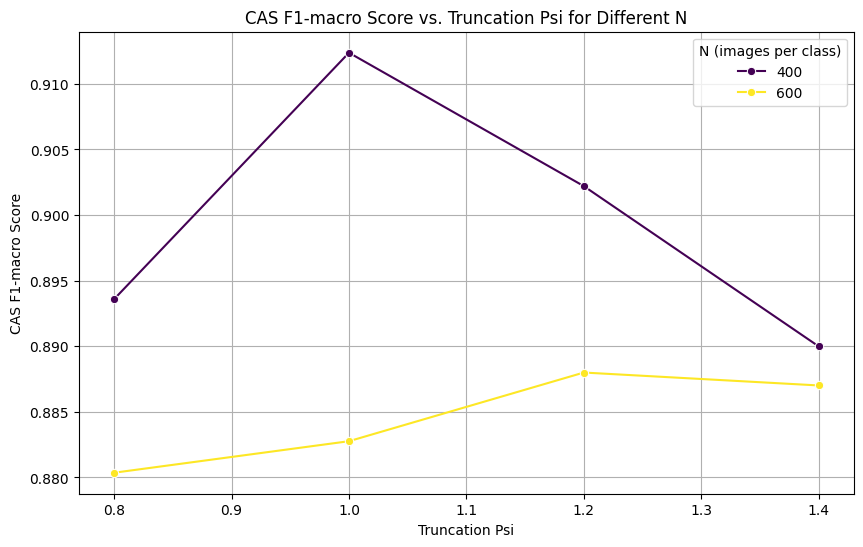

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x="psi", y="CAS_f1_macro", hue="N", marker="o", palette="viridis")
plt.title("CAS F1-macro Score vs. Truncation Psi for Different N")
plt.xlabel("Truncation Psi")
plt.ylabel("CAS F1-macro Score")
plt.grid(True)
plt.legend(title="N (images per class)")
plt.show()